# Feature Engineering

## Install dependencies

In [1]:
%pip install\
    pandas\
    scikit-learn\
    matplotlib\
    seaborn

Note: you may need to restart the kernel to use updated packages.


## Load dataset

In [2]:
data_dir = '../data'
data_processed_dir = data_dir + '/processed'
data_processed = data_processed_dir + '/filmes.csv'

In [3]:
import pandas as pd

In [4]:
def convert_to_list(x):
    return [t.replace("'", "").replace('"', '') for t in x.strip("[]").split(", ")]

In [5]:
df = pd.read_csv(
    data_processed,
    converters={
        'genres_list': convert_to_list,
        'sinopse_tokens': convert_to_list
    })

In [6]:
df.head()

,genres,averageRating,numVotes,sinopse,primaryTitle,startYear,runtimeMinutes,actors_names,directors_names,genres_list,sinopse_clean,sinopse_tokens
0,Family,7.1,387992,When two kids find and play a magical board ga...,Jumanji,1995,104,['Robin Williams' 'Jonathan Hyde' 'Jonathan Hy...,['Joe Johnston'],[Family],when two kids find and play a magical board ga...,"[kid, find, play, magical, board, game, releas..."
1,Romance,6.7,30265,John and Max resolve to save their beloved bai...,Grumpier Old Men,1995,101,['Walter Matthau' 'Jack Lemmon' 'Burgess Mered...,['Howard Deutch'],[Romance],john and max resolve to save their beloved bai...,"[john, max, resolve, save, beloved, bait, shop..."
2,Romance,6.0,12585,"Based on Terry McMillan's novel, this film fol...",Waiting to Exhale,1995,124,['Gregory Hines' 'Dennis Haysbert' 'Mykelti Wi...,['Forest Whitaker'],[Romance],based on terry mcmillan's novel this film foll...,"[base, terry, mcmillan, novel, film, follow, d..."
3,"Romance,Family",6.1,42555,George Banks must deal not only with his daugh...,Father of the Bride Part II,1995,106,['Steve Martin' 'Martin Short' 'George Newbern...,['Charles Shyer'],"[Romance, Family]",george banks must deal not only with his daugh...,"[george, bank, deal, daughter, pregnancy, wife]"
4,"Crime,Action",8.3,738636,A group of high-end professional thieves start...,Heat,1995,170,['Al Pacino' 'Robert De Niro' 'Val Kilmer' 'Jo...,['Michael Mann'],"[Crime, Action]",a group of highend professional thieves start ...,"[group, highend, professional, thief, start, f..."


## Tf-idf vectorization

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [8]:
def identity(x):
    return x

In [16]:
vectorizer = TfidfVectorizer(
    # adjust for the preprocessed tokenized text
    analyzer=identity,
    token_pattern=None,
    lowercase=False,
    
    ngram_range=(1, 2),
    min_df=5
)

X = vectorizer.fit_transform(df['sinopse_tokens'])
feature_names = vectorizer.get_feature_names_out()

/home/srjheam/projects/ufes-cdados-movie-synopsis-clustering/.venv/lib/python3.11/site-packages/sklearn/feature_extraction/text.py:533: UserWarning: The parameter 'ngram_range' will not be used since 'analyzer' is callable'
  warnings.warn(


In [17]:
X.todense()

matrix([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], shape=(30358, 9388))

In [18]:
feature_names

array(['aaron', 'aback', 'abandon', ..., 'zorro', 'zoya', 'zurich'],
      shape=(9388,), dtype=object)

In [19]:
df_tfidf = pd.DataFrame(
    X.toarray(),
    columns=feature_names
)

In [20]:
df_tfidf

,aaron,aback,abandon,abbot,abbott,abby,abduct,abducted,abduction,abductor,...,ziegfeld,zoe,zombie,zombielike,zone,zoo,zoologist,zorro,zoya,zurich
0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30353,0.0,0.0,0.06636,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
30354,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
30355,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
30356,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Dimensionality reduction

In [21]:
from sklearn.decomposition import TruncatedSVD

In [28]:
svd = TruncatedSVD(n_components=250, random_state=42)
svd_matrix = svd.fit_transform(df_tfidf)
print(f"Reduced {df_tfidf.shape[1]} to {svd_matrix.shape[1]} components")

Reduced 9388 to 250 components


In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

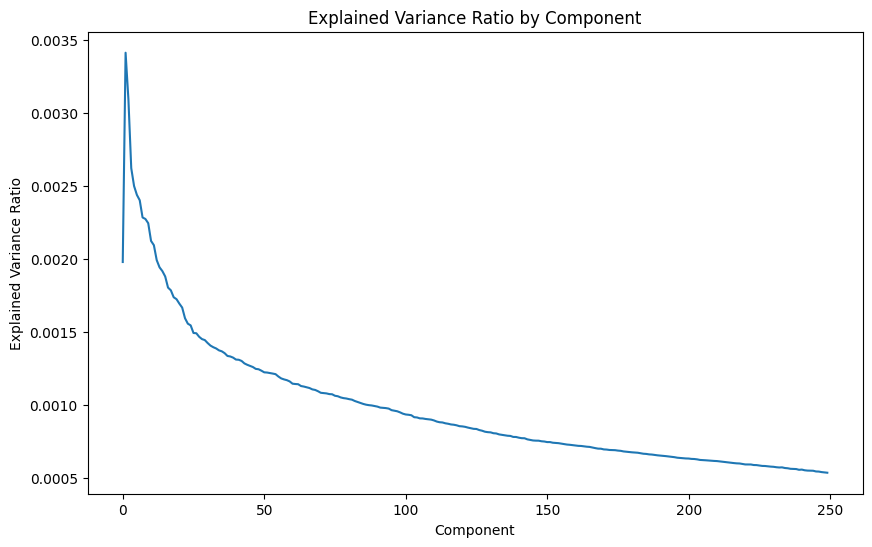

In [29]:
# plot explained variance ratio

plt.figure(figsize=(10, 6))
sns.lineplot(
    x=range(svd.explained_variance_ratio_.shape[0]),
    y=svd.explained_variance_ratio_
)
plt.xlabel('Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance Ratio by Component')
plt.show()